In [1]:
import torch
import torch.nn.functional as F

# load moby dick
with open('data/pg2701.txt', 'r') as fobj:
    mobydick = fobj.read()
mobydick = mobydick.split('\n')

# find the first line of the actual text
for i, line in enumerate(mobydick):
    if "Call me Ishmael" in line:
        break
all_text = ' '.join(mobydick[i:])

In [2]:
all_text[:30]

'Call me Ishmael. Some years ag'

In [3]:
import re
all_words = re.findall('[a-zA-Z]+', all_text)
all_words_lower = list(map(lambda word: word.lower(), all_words))

In [4]:
all_words_lower

['call',
 'me',
 'ishmael',
 'some',
 'years',
 'ago',
 'never',
 'mind',
 'how',
 'long',
 'precisely',
 'having',
 'little',
 'or',
 'no',
 'money',
 'in',
 'my',
 'purse',
 'and',
 'nothing',
 'particular',
 'to',
 'interest',
 'me',
 'on',
 'shore',
 'i',
 'thought',
 'i',
 'would',
 'sail',
 'about',
 'a',
 'little',
 'and',
 'see',
 'the',
 'watery',
 'part',
 'of',
 'the',
 'world',
 'it',
 'is',
 'a',
 'way',
 'i',
 'have',
 'of',
 'driving',
 'off',
 'the',
 'spleen',
 'and',
 'regulating',
 'the',
 'circulation',
 'whenever',
 'i',
 'find',
 'myself',
 'growing',
 'grim',
 'about',
 'the',
 'mouth',
 'whenever',
 'it',
 'is',
 'a',
 'damp',
 'drizzly',
 'november',
 'in',
 'my',
 'soul',
 'whenever',
 'i',
 'find',
 'myself',
 'involuntarily',
 'pausing',
 'before',
 'coffin',
 'warehouses',
 'and',
 'bringing',
 'up',
 'the',
 'rear',
 'of',
 'every',
 'funeral',
 'i',
 'meet',
 'and',
 'especially',
 'whenever',
 'my',
 'hypos',
 'get',
 'such',
 'an',
 'upper',
 'hand',
 '

In [5]:
# create a vocabulary: list of unique words
vocab = list(set(all_words_lower))

# assign each word to an integer from 1...V=len(vocab), and vice versa
w_to_i = {word: i for i, word in enumerate(vocab)}
i_to_w = {i: word for i, word in enumerate(vocab)}

In [7]:
len(vocab)

16877

In [10]:
w_to_i['call'],i_to_w[10749]

(10749, 'call')

In [11]:
V = len(vocab) # number of possible words
N = len(all_words_lower) # length of the actual text

window = 2 # desired number of words to use for next-word prediction

all_idxs = [w_to_i[word] for word in all_words_lower]

X, Y = [], []
for k in range(N - window-1):
    X.append(all_idxs[k : k+window])
    Y.append(all_idxs[k+window])

X = torch.tensor(X)
Y = torch.tensor(Y)


# # build a one-hot encoding
# # use sparse data structure to save memory
# row_idx = torch.arange(N, dtype=torch.int32)
# col_idx = torch.tensor([w_to_i[word] for word in all_words_lower], dtype=torch.int32)
# indices = torch.stack([row_idx, col_idx])
# values = torch.ones(N, dtype=torch.float64)

# Xsp = torch.sparse_coo_tensor(indices, values)
# Xsp.shape # (N, V)

In [12]:
X[:5], Y[:5]

(tensor([[10749,  8512],
         [ 8512,  3276],
         [ 3276,  7101],
         [ 7101, 11193],
         [11193,  5167]]),
 tensor([ 3276,  7101, 11193,  5167,  7729]))

In [14]:
# now create a dense embedding of words: a random d-dimensional vector for each word
embed_dim = 16
C = torch.randn((V, embed_dim), requires_grad=True) # this is a large matrix! one row for every word

C.shape, C[X].shape

(torch.Size([16877, 16]), torch.Size([217613, 2, 16]))

In [16]:
# create a NN of the same structure as we used for character embedding
# note: we now need V many probabilities since we have V possible words! many many more than 27!
hidden_dim = 200 # number of hidden units

W1 = torch.randn((window * embed_dim, hidden_dim), requires_grad=True)
b1 = torch.randn(hidden_dim, requires_grad=True)

W2 = torch.randn((hidden_dim, V), requires_grad=True)
b2 = torch.randn(V, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

In [17]:
# forward pass

batch_idx = torch.randint(0, N-window-1, (64,))

hidden_activations = (C[X[batch_idx]].view((-1, window * embed_dim)) @ W1 + b1).tanh()
logits = (hidden_activations @ W2 + b2)

loss = F.cross_entropy(logits, Y[batch_idx])
loss.item()

51.69670867919922

In [18]:
loss_values = []

In [20]:
# SGD, i.e. do minibatches
# apply GD in a loop
h = 0.1 # step size
for step in range(1000):
    for p in parameters:
        p.grad = None
    
    # minibatch selection
    batch_idx = torch.randint(0, N-window-1, (64,))

    hidden_activations = (C[X[batch_idx]].view((-1, window * embed_dim)) @ W1 + b1).tanh()
    logits = (hidden_activations @ W2 + b2)

    loss = F.cross_entropy(logits, Y[batch_idx])
    loss_values.append(loss.item())
    if step % 100 == 0:
        print(loss.item())

    loss.backward()
    for p in parameters:
        p.data -= h * p.grad

36.71625900268555
34.85871887207031
32.542724609375
37.630714416503906
35.91357421875
32.681392669677734
31.05367660522461
30.852014541625977
29.702272415161133
29.55716323852539


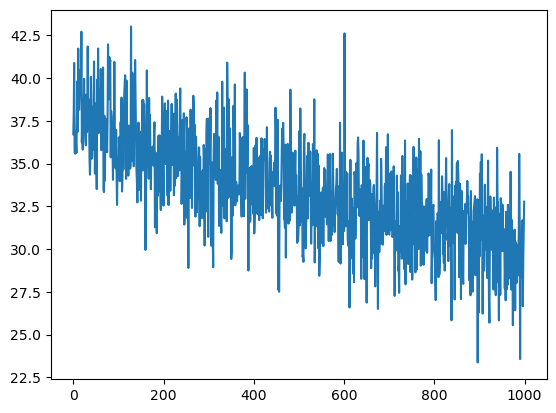

In [21]:
import matplotlib.pyplot as plt
plt.plot(loss_values)

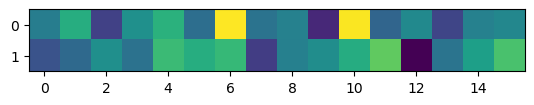

In [26]:
plt.imshow(torch.stack([C[w_to_i['her']], C[w_to_i['him']]]).detach().numpy())